# Model Trainer

## Imports

In [1]:
# load
import os
import re

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1' # 1
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/"
# os.environ["TF_GPU_ALLOCATOR"]='cuda_malloc_async'

import tensorflow as tf
keras = tf.keras # fixes issues with vsCode
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt

from functools import partial

from keras import Input, Model
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Layer, LeakyReLU, Add, UpSampling2D, Activation, SpatialDropout2D, Conv2D, BatchNormalization, Concatenate, Flatten, Dense, RandomRotation, RandomFlip, RandomZoom
from keras.optimizers import Adam
from tensorflow_addons.layers import InstanceNormalization

from IPython.display import clear_output
from datetime import datetime

from tensorflow import pad

from keras.callbacks import LambdaCallback, TensorBoard, EarlyStopping, ModelCheckpoint, LearningRateScheduler

%matplotlib inline

tf.debugging.set_log_device_placement(False)

print(f'tf version: {tf.__version__}')
plt.rcParams.update({'font.size': 13})
tf.config.list_physical_devices('GPU')

2023-04-10 10:08:52.856592: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cudnn-8.2.4.15-11.4-eluwegpwn6adr7hlku5p5wru5xzefpop/lib64:/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/lib64
2023-04-10 10:08:52.856806: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cudnn-8.2.4.15-11.4-eluwegpwn6adr7hlku5p5wru5xzefpop/lib64:/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/lib64
2023-04-10 10:08:52.

tf version: 2.11.0


2023-04-10 10:08:57.275102: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cudnn-8.2.4.15-11.4-eluwegpwn6adr7hlku5p5wru5xzefpop/lib64:/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/lib64
2023-04-10 10:08:57.275166: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)


[]

In [2]:
strategy = tf.distribute.MirroredStrategy()
# stragety = tf.distribute.OneDeviceStrategy(device="/gpu:0") # for debugging

# some base settings
model_name = 'camb_3'
data_dir = f'data/{model_name}'
model_dir = f'data/models/{model_name}'
plot_dir = f'data/plots/{model_name}'
tb_dir = f'data/tensorboard/{model_name}'
use_tensorboard = True

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


## TensorBoard

In [3]:
%load_ext tensorboard
# %tensorboard --logdir data/tb/ --port 23465
print('open http://localhost:23465/')

open http://localhost:23465/


## Model Code

In [4]:
def load_data(data_dir, interp, base_name):
    # load fnls, which are in the base dir
    fnls = np.load(f'{data_dir}/{base_name}-fnls.npy')
    
    # List all files in data_dir
    data_dir = f'{data_dir}/{interp}' # currently, we are adding the interp to the path to allow testing of liner vs cubic
    all_files = os.listdir(data_dir)

    # Filter files that match the base_name and specific format
    pattern = re.compile(f'{base_name}_\d+-\d+\.npy')
    filtered_files = [file for file in all_files if pattern.match(file)]

    # Sort files based on the first range value
    filtered_files.sort(key=lambda x: int(re.search('\d+', x).group()))

    # Load data from files and append to a list
    data_list = []
    for file in filtered_files:
        file_path = os.path.join(data_dir, file)
        data = np.load(file_path)
        data_list.append(data)

    # Concatenate data into a single numpy array
    data_array = np.concatenate(data_list, axis=0)

    return data_array, fnls

### Helper Functions

In [5]:
kF = 2*np.pi/1000.

class ReflectionPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4)]
        super(ReflectionPadding2D, self).__init__(**kwargs)

    def compute_output_shape(self, s):
        """ If you are using "channels_last" configuration"""
        return (s[0], s[1] + 2 * self.padding[0], s[2] + 2 * self.padding[1], s[3])

    def call(self, x, mask=None):
        w_pad,h_pad = self.padding
        return pad(x, [[0,0], [h_pad,h_pad], [w_pad,w_pad], [0,0] ], 'REFLECT')


def create_localization_module(input_layer, n_filters):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(layer1, n_filters)
    convolution2 = create_convolution_block(convolution1, n_filters, kernel=(1, 1))
    return convolution2


def create_up_sampling_module(input_layer, n_filters, size=(2, 2)):
    up_sample = UpSampling2D(size=size)(input_layer)
    layer1 = ReflectionPadding2D()(up_sample)
    convolution = create_convolution_block(layer1, n_filters)
    return convolution


def create_context_module(input_layer, n_level_filters, dropout_rate=0.1, data_format="channels_last"):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(input_layer=layer1, n_filters=n_level_filters)
    dropout = SpatialDropout2D(rate=dropout_rate, data_format=data_format)(convolution1)
    layer2 = ReflectionPadding2D()(dropout)
    convolution2 = create_convolution_block(input_layer=layer2, n_filters=n_level_filters)
    return convolution2


def create_convolution_block(input_layer, n_filters, batch_normalization=False, kernel=(3, 3), activation=LeakyReLU,
                             padding='valid', strides=(1, 1), instance_normalization=False):
    """
    :param strides:
    :param input_layer:
    :param n_filters:
    :param batch_normalization:
    :param kernel:
    :param activation: Keras activation layer to use. (default is 'relu')
    :param padding:
    :return:
    """
    layer = Conv2D(n_filters, kernel, padding=padding, strides=strides)(input_layer)
    if batch_normalization:
        layer = BatchNormalization()(layer)
    elif instance_normalization:
        layer = InstanceNormalization()(layer)
    if activation is None:
        return Activation('relu')(layer)
    else:
        return activation()(layer)

def dice_coefficient(y_true, y_pred, smooth=1.):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_coefficient_loss(y_true, y_pred):
    return -dice_coefficient(y_true, y_pred)


### Model Architecture

#### isensee2017

In [6]:
# with stragety.scope():
#     create_convolution_block = partial(create_convolution_block, activation=LeakyReLU, instance_normalization=True)


def isensee2017_model(inputs, n_base_filters=16, depth=5, dropout_rate=0.3,
                      n_segmentation_levels=3, n_labels=1, optimizer=Adam, initial_learning_rate=5e-4,
                      loss_function=dice_coefficient_loss, activation_name="relu", preprocess=False):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        # inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)
        
    current_layer = inputs
    level_output_layers = list()
    level_filters = list()
    for level_number in range(depth):
        #n_level_filters = (2**level_number) * n_base_filters
        n_level_filters = 8
        level_filters.append(n_level_filters)
        
        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(in_conv, n_level_filters, dropout_rate=dropout_rate)

        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    segmentation_layers = list()
    for level_number in range(depth-2, -1, -1):
        up_sampling = create_up_sampling_module(current_layer, level_filters[level_number])
        concatenation_layer = Concatenate()([level_output_layers[level_number], up_sampling])
        localization_output = create_localization_module(concatenation_layer, level_filters[level_number])
        current_layer = localization_output
        if level_number < n_segmentation_levels:
            segmentation_layers.insert(0, Conv2D(n_labels, (1, 1))(current_layer))

    output_layer = None
    for level_number in reversed(range(n_segmentation_levels-1)):
        segmentation_layer = segmentation_layers[level_number]
        if output_layer is None:
            output_layer = segmentation_layer
        else:
            output_layer = Add()([output_layer, segmentation_layer])

        if level_number > 0:
            output_layer = UpSampling2D(size=(2, 2))(output_layer)

    flat_layer = Flatten()(output_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer)
    model.compile(optimizer=optimizer(learning_rate=initial_learning_rate), loss=loss_function, metrics=tf.keras.metrics.RootMeanSquaredError())
    return model


#### Custom BS

In [7]:
def make_model(inputs, n_base_filters=16, depth=5, dropout_rate=0.3,
                      n_segmentation_levels=3, n_labels=1, optimizer=Adam, initial_learning_rate=5e-4,
                      loss_function=dice_coefficient_loss, activation_name="relu", preprocess=False):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)
        
    current_layer = inputs
    level_output_layers = list()
    level_filters = list()
    for level_number in range(depth):
        n_level_filters = 16# 2**(depth-level_number) #* n_base_filters
        level_filters.append(n_level_filters)
        
        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(in_conv, n_level_filters, dropout_rate=dropout_rate)
        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    # segmentation_layers = list()
    # for level_number in range(depth-2, -1, -1):
    #     concatenation_layer = level_output_layers[level_number]
    #     localization_output = create_localization_module(concatenation_layer, level_filters[level_number])
    #     current_layer = localization_output
    #     if level_number < n_segmentation_levels:
    #         segmentation_layers.insert(0, Conv2D(n_labels, (1, 1))(current_layer))

    # output_layer = None
    # for level_number in reversed(range(n_segmentation_levels-1)):
    #     segmentation_layer = segmentation_layers[level_number]
    #     if output_layer is None:
    #         output_layer = segmentation_layer
    #     else:
    #         output_layer = Add()([output_layer, segmentation_layer])

    #     if level_number > 0:
    #         output_layer = UpSampling2D(size=(2, 2))(output_layer)

    flat_layer = Flatten()(current_layer)
    out_layer = Dense(1,activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=base_name)
    model.compile(optimizer=optimizer(learning_rate=initial_learning_rate), loss=loss_function, metrics=tf.keras.metrics.RootMeanSquaredError())
    return model

## Load Data

In [8]:
# These settings should match the generation settings, from there it will just load the files correctly
img_size=128
train_size=10000
fnl_range=[-1000,1000]
interp='cubic'

basename=f'{img_size}x{train_size//1000}k_fnl{fnl_range[0]}-{fnl_range[1]}'
run_time = datetime.now().strftime("%Y%m%d-%H%M%S")

# update data_dir to match conventions
data_dir = f'{data_dir}/{basename}/'

# model settins, will also be used to inform data loading
batch_size=256
max_epochs=100

In [9]:
N_train = int(train_size*0.8)
N_val = int(train_size*0.1)
N_test = int(train_size*0.1)

X_data, y_data = load_data(data_dir, interp, basename)

# split into training and testing data
X_train = X_data[:N_train]
X_test = X_data[N_train:N_train+N_test]
X_val = X_data[N_train+N_test:]

y_train = y_data[:N_train]
y_test = y_data[N_train:N_train+N_test]
y_val = y_data[N_train+N_test:]

print(X_train.shape,X_val.shape,X_test.shape,y_train.shape,y_val.shape,y_test.shape)

# Our sets are not big enought to do really complex loading into ram, but we still need to do stuff for the gpu
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

(8000, 128, 128) (1000, 128, 128) (1000, 128, 128) (8000,) (1000,) (1000,)


### Check Data

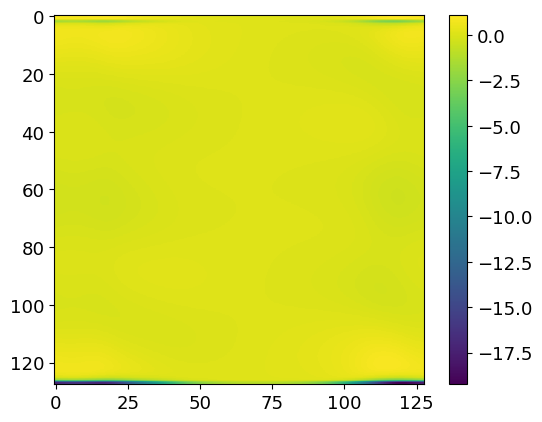

In [10]:
plt.imshow(X_data[0])
plt.colorbar()
plt.show()

## Train Model

### Compile Model

In [11]:
# with stragety.scope():
#     img_size=128
#     input_img = Input((img_size, img_size, 1), name='img')
#     model = isensee2017_model(input_img, depth=5, n_segmentation_levels=3,dropout_rate=0.3,loss_function=tf.keras.losses.mse,initial_learning_rate=1e-3)
#     model.summary()

with strategy.scope():
    input_img = Input((img_size, img_size, 1), name='img')
    model = make_model(input_img, depth=3, n_segmentation_levels=0, dropout_rate=0.5,loss_function=tf.keras.losses.mse,initial_learning_rate=1e-3, preprocess=True)
    model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                  
 reflection_padding2d (Reflecti  (None, 130, 130, 1)  0          ['input_1[0][0]']                
 onPadding2D)                                                                                     
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 16  160         ['reflection_padding2d[1][0]']   
                                )                                                             

### Train

In [12]:
%%time

#Help keep the output clean in VS Code, might want to remove this if you're not using VS Code
def clearOutput(batch, logs):
    clear_output(wait=True)
    pass

with strategy.scope(): 
    # K.set_value(model.optimizer.learning_rate, 0.0001)
    
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-5,
        decay_steps=10000,
        decay_rate=0.9)
    
    callbacks = [
        # EarlyStopping( monitor="val_loss", patience=8), 
        ModelCheckpoint(filepath=f'{model_dir}/checkpoint_{run_time}.keras', 
                        monitor="val_root_mean_squared_error", 
                        save_best_only=True),
        LearningRateScheduler(lr_schedule),
        LambdaCallback(on_epoch_begin=clearOutput),
        ]
    if use_tensorboard:
        logs = f'{tb_dir}/{basename}_{run_time}'
        callbacks.append(TensorBoard(log_dir=logs))
    
    model.fit(train_dataset, validation_data=test_dataset, batch_size=batch_size, epochs=max_epochs, callbacks=callbacks)

Epoch 12/100


KeyboardInterrupt: 

### Validation

In [ ]:
# check the accuracy of some training data
preds = model.predict(X_train,batch_size=batch_size,verbose="auto")[:,0]
truth = y_train
rmse = np.sqrt(((preds-truth)**2).mean())

plt.plot(truth,preds,".")
plt.plot(truth,truth,".")
plt.title(f"RMSE = {rmse}")
plt.xlabel('truth (train)')
plt.grid()
plt.ylabel('prediction')

plt.savefig(f"{plot_dir}/{basename}_train.png")
plt.show()

In [ ]:
# check the accuracy of some training data
preds = model.predict(X_val,batch_size=batch_size,verbose="auto")[:,0]
truth = y_val
rmse = np.sqrt(((preds-truth)**2).mean())

plt.plot(truth,preds,".")
plt.plot(truth,truth,".")
plt.title(f"RMSE = {rmse}")
plt.xlabel('truth (val)')
plt.grid()
plt.ylabel('prediction')

plt.savefig(f"{plot_dir}/{basename}_val.png")
plt.show()

In [ ]:
# check the accuracy of some training data
preds = model.predict(X_test,batch_size=batch_size,verbose="auto")[:,0]
truth = y_test
rmse = np.sqrt(((preds-truth)**2).mean())

plt.plot(truth,preds,".")
plt.plot(truth,truth,".")
plt.title(f"RMSE = {rmse}")
plt.xlabel('truth (test)')
plt.grid()
plt.ylabel('prediction')

plt.savefig(f"{plot_dir}/{basename}_test.png")
plt.show()

In [ ]:
z_data = np.load("data/linear-thomas/squaremaps_G.npy")[:,:,:,np.newaxis]
z_data.shape

preds_0 = model.predict(z_data,batch_size=batch_size)

plt.hist(preds_0,bins=100)
plt.show()
preds_0.mean(), preds_0.std()

In [ ]:
z_data = np.load("data/linear-thomas/squaremaps_NG_100.npy")[:,:,:,np.newaxis]
z_data.shape

preds_0 = model.predict(z_data,batch_size=batch_size)

plt.hist(preds_0,bins=100)
plt.show()
preds_0.mean(), preds_0.std()

### Save Model

In [ ]:
modelfile = f'{model_dir}/{basename}_{run_time}'
model.save(modelfile)